# Privacy-Aware Hospital Readmission Analysis and Prediction with Safe Synthesizer

#### What you'll learn

In this notebook, we'll build a privacy-aware hospital readmissions workflow with NeMo Safe Synthesizer. You'll learn how to manually configure replacement for columns that commonly contain sensitive healthcare data, generate synthetic admissions, interpret built-in quality and privacy evaluations, inspect healthcare-specific relationships, and test whether the generated data supports downstream readmission modeling.

We will answer three questions:

1. Does the Synthetic data preserve the utilization, payer, and clinical patterns found in the Original data?
2. What do the built-in quality and privacy evaluations tell us about the generated data?
3. Can a model trained on Synthetic data transfer to a held-out Original cohort?

> **Important terminology: the Original dataset used in this notebook is also synthetic.** The provided Original dataset was generated with [NVIDIA NeMo Data Designer](https://docs.nvidia.com/nemo/datadesigner/getting-started/welcome), is entirely simulated, and contains no real patient data. Throughout this tutorial and its plots, **Original** means this simulated input dataset, while **Synthetic** means the new dataset generated from it by Safe Synthesizer. The simulated identifiers and clinical details let us demonstrate a workflow that could be applied to restricted data under an organization's approved privacy and governance controls.

## 1. Environment

Run the cell below to install NeMo Safe Synthesizer with the engine and CUDA 12.9 extras. If it is already installed in your notebook environment, you can skip this cell. A CUDA GPU is required for training and generation.

In [ ]:
%%bash
# SPDX-FileCopyrightText: Copyright (c) 2025-2026 NVIDIA CORPORATION & AFFILIATES. All rights reserved.
# SPDX-License-Identifier: Apache-2.0

if command -v uv > /dev/null 2>&1; then
    uv pip install "nemo-safe-synthesizer[engine,cu129]" xgboost \
        --index https://flashinfer.ai/whl/cu129 \
        --index https://flashinfer.ai/whl/ \
        --index https://download.pytorch.org/whl/cu129 \
        --index https://wheels.vllm.ai/0.26.0/cu129 \
        --index-strategy unsafe-best-match
else
    pip install "nemo-safe-synthesizer[engine,cu129]" xgboost \
        --extra-index-url https://flashinfer.ai/whl/cu129 \
        --extra-index-url https://flashinfer.ai/whl/ \
        --extra-index-url https://download.pytorch.org/whl/cu129 \
        --extra-index-url https://wheels.vllm.ai/0.26.0/cu129
fi

In [ ]:
# SPDX-FileCopyrightText: Copyright (c) 2026 NVIDIA CORPORATION & AFFILIATES. All rights reserved.
# SPDX-License-Identifier: Apache-2.0

import base64
import time

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import IFrame, Markdown, display

NVIDIA_GREEN = "#76B900"
NVIDIA_DARK = "#1A1A1A"
plt.rcParams.update({"figure.figsize": (10, 5), "axes.spines.top": False, "axes.spines.right": False})

## 2. Load the simulated admissions

The Original dataset is provided with this tutorial, and postal codes are loaded as strings.

In [3]:
source_df = pd.read_csv(
    "datasets/hospital_readmissions_synthetic_2026_08_18.csv",
    dtype={"postal_code": "string"},
)

print(f"Loaded {len(source_df):,} simulated admissions with {source_df.shape[1]} fields.")

Loaded 9,997 simulated admissions with 33 fields.


In [3]:
PREVIEW_COLUMNS = [
    "age", "sex", "insurance_type", "encounter_type",
    "primary_diagnosis", "icd10_code", "primary_lab_name",
    "primary_lab_value", "primary_lab_unit", "primary_lab_flag",
    "length_of_stay_days", "discharge_disposition",
    "total_charge_usd", "readmitted_within_30_days",
]
source_df[PREVIEW_COLUMNS].head()

,age,sex,insurance_type,encounter_type,primary_diagnosis,icd10_code,primary_lab_name,primary_lab_value,primary_lab_unit,primary_lab_flag,length_of_stay_days,discharge_disposition,total_charge_usd,readmitted_within_30_days
0,33,Male,Commercial,Emergency inpatient,Diabetic ketoacidosis,E11.10,Serum glucose,539.6,mg/dL,H,4,Home or self-care,26888.65,False
1,36,Female,Commercial,Emergency inpatient,Diabetic ketoacidosis,E11.10,Serum glucose,259.9,mg/dL,H,5,Skilled nursing facility,28755.55,True
2,29,Male,Commercial,Emergency inpatient,Community-acquired pneumonia,J18.9,White blood cell count,17.7,K/uL,H,2,Home with home health,16699.50,False
3,21,Male,Commercial,Emergency inpatient,Diabetic ketoacidosis,E11.10,Serum glucose,548.4,mg/dL,H,3,Skilled nursing facility,19888.97,False
4,24,Female,Medicaid,Emergency inpatient,Diabetic ketoacidosis,E11.10,Serum glucose,596.5,mg/dL,H,5,Home with home health,34262.71,False


## 3. Configure healthcare sensitive-data replacement

Personally identifiable information (PII) is information that can identify a person. In healthcare, identifiable information about a person's health or care may be protected health information (PHI). Although this tutorial uses simulated data, its columns resemble fields that would require careful handling in a real healthcare workflow.

NeMo Safe Synthesizer can ask a large language model (LLM) to identify structured columns that may contain sensitive values. That automatic option requires credentials for the configured LLM service. Because the columns and their meanings are already known here, this tutorial lists them manually instead. The resulting policy is easy to review and column classification does not require an external service.

Structured columns and free-form text need different rules. The explicit rules below replace patient and admission identifiers, medical record numbers (MRNs), names, contact details, locations, and dates. A named-entity recognition (NER) model running in the notebook environment finds names, MRNs, and dates embedded in discharge summaries. The NER model may download its files the first time it is used, but it does not use the LLM column-classification service.

Repeated identifiers map to the same replacements, and each patient receives a consistent name and email. Date of birth (DOB), admission, and discharge dates move by the same 7–90-day patient-specific offset, preserving age, visit order, and length of stay. PII replacement runs before fine-tuning, so the source identifiers in the training partition are replaced before the model is trained.

In [ ]:
from nemo_safe_synthesizer.config.replace_pii import PiiReplacerConfig, Row

# Keep the data split and generated replacements reproducible across tutorial runs.
SPLIT_SEED = 318
# Extra fixed input to deterministic identifier hashes; use an approved value in production.
HASH_SALT = "nss-healthcare-readmissions-demo-2026"

def build_healthcare_pii_config() -> PiiReplacerConfig:
    config = PiiReplacerConfig.get_default_config()
    config.globals.seed = SPLIT_SEED
    # The structured columns are listed below, so LLM-based classification is unnecessary.
    config.globals.classify.enable_classify = False
    config.globals.ner.ner_entities = [
        "first_name", "last_name", "name",
        "medical_record_number", "date", "date_time",
    ]

    stable_hash = f"(this | hash(salt='{HASH_SALT}'))"
    uuid_parts = [(0, 8), (8, 12), (12, 16), (16, 20), (20, 32)]
    patient_uuid = " + '-' + ".join(f"{stable_hash}[{start}:{end}]" for start, end in uuid_parts)
    patient_seed = f"(row.patient_id | hash(salt='{HASH_SALT}'))"
    persona = f"fake.persona(row_index={patient_seed}, gender=row.sex)"
    date_offset = f"7 + ((({patient_seed}[0:8]) | int(base=16)) % 84)"
    shifted_date = f"((this | date_parse) + timedelta(days={date_offset}))"

    config.steps[0].rows.update = [
        Row(name="admission_id", value=f"'ADM-' + ({stable_hash}[0:16] | upper)"),
        Row(name="patient_id", value=patient_uuid),
        Row(name="mrn", value=f"'MRN-' + ({stable_hash}[0:12] | upper)"),
        Row(name="full_name", value=f"{persona}.first_name + ' ' + {persona}.last_name"),
        Row(name="email", value=f"{persona}.email"),
        Row(
            name="phone",
            value="(fake.random_number(digits=3) | string) + '-' + (fake.random_number(digits=3) | string) + '-' + (fake.random_number(digits=4) | string)",
        ),
        Row(name="address", value="'street_address' | fake"),
        Row(name="city", value="'city' | fake"),
        Row(name="state", value="'state_abbr' | fake"),
        Row(name="postal_code", value="'postcode' | fake"),
        Row(name="date_of_birth", value=f"{shifted_date} | date_format"),
        Row(name="admission_datetime", value=f"{shifted_date} | date_time_format(format='%Y-%m-%dT%H:%M:%S')"),
        Row(name="discharge_datetime", value=f"{shifted_date} | date_time_format(format='%Y-%m-%dT%H:%M:%S')"),
        Row(name="discharge_summary", value="this | fake_entities(on_error='hash')"),
    ]
    return config

pii_config = build_healthcare_pii_config()
print(f"Configured {len(pii_config.steps[0].rows.update or [])} PII replacement rules.")

## 4. Train, generate, and evaluate

The next cell runs the complete Safe Synthesizer pipeline. It sets aside 499 Original records for evaluation, applies the PII replacement policy to the remaining 9,498 records before fine-tuning the default SmolLM3 model, generates 5,000 Synthetic records, and evaluates the result. The generated data, trained model adapter (the learned model update), metrics, and HTML report are saved automatically under `ARTIFACT_ROOT`. The adapter can be reused for later generation without repeating fine-tuning.

> **Runtime:** This run took about an hour on an NVIDIA A100. A first run may take longer while model files are downloaded.

This tutorial does not enable differential privacy (DP) because its 9,997 input rows fall just below the documented recommendation of at least 10,000 rows. PII replacement and privacy evaluation are still enabled, but they do not provide a formal DP guarantee. See the [Differential Privacy tutorial](differential-privacy.ipynb) for that workflow.

In [6]:
from nemo_safe_synthesizer.sdk.library_builder import SafeSynthesizer

ARTIFACT_ROOT = "safe-synthesizer-healthcare-artifacts"
builder = (
    SafeSynthesizer(save_path=ARTIFACT_ROOT)
    .with_data_source(source_df)
    .with_replace_pii(config=pii_config)
    .with_data(random_state=SPLIT_SEED)
    .with_generate(num_records=5_000)
)

run_started = time.perf_counter()
builder.run()
run_elapsed_minutes = (time.perf_counter() - run_started) / 60
results = builder.results
synthetic_df = results.synthetic_data.copy()

assert len(synthetic_df) == 5_000, f"Expected 5,000 generated records, found {len(synthetic_df):,}."
print(f"Completed the full pipeline in {run_elapsed_minutes:.1f} minutes.")
print(f"Generated {len(synthetic_df):,} synthetic admissions.")

Completed the full pipeline in 57.6 minutes.
Generated 5,000 synthetic admissions.


In [2]:
display(synthetic_df[PREVIEW_COLUMNS].head())

,age,sex,insurance_type,encounter_type,primary_diagnosis,icd10_code,primary_lab_name,primary_lab_value,primary_lab_unit,primary_lab_flag,length_of_stay_days,discharge_disposition,total_charge_usd,readmitted_within_30_days
0,29,Female,Commercial,Elective inpatient,Hip osteoarthritis,M16.9,Hemoglobin,10.1,g/dL,L,3,Home with home health,28049.14,False
1,71,Male,Medicare,Emergency inpatient,Diabetic ketoacidosis,E11.10,Serum glucose,303.5,mg/dL,H,5,Home or self-care,27866.53,False
2,29,Male,Commercial,Emergency inpatient,COPD exacerbation,J44.1,Oxygen saturation,85.3,%,L,5,Skilled nursing facility,29433.26,False
3,47,Male,Medicaid,Emergency inpatient,Heart failure,I50.9,B-type natriuretic peptide,389.9,pg/mL,H,4,Skilled nursing facility,26400.25,False
4,58,Male,Commercial,Emergency inpatient,Community-acquired pneumonia,J18.9,White blood cell count,13.2,K/uL,H,6,Home or self-care,37067.03,False


### Built-in SQS, DPS, and HTML report

The Synthetic Data Quality Score (SQS) summarizes statistical similarity, while the Data Privacy Score (DPS) summarizes the built-in privacy evaluation. Both use a 0–10 scale, where higher is better. Open the HTML report to inspect the component scores and identify distributions, relationships, or privacy risks that need attention. These results support review; they do not certify compliance or automatically approve the data for sharing.

In [8]:
report_html = results.evaluation_report_html
if report_html:
    report_url = "data:text/html;base64," + base64.b64encode(report_html.encode("utf-8")).decode("ascii")
    display(IFrame(src=report_url, width="100%", height=850))
else:
    display(Markdown("The run did not return an HTML evaluation report."))

## 5. Healthcare utility checks

These comparisons test whether the Synthetic data preserves patterns from the Original data well enough to support descriptive utilization analysis. Similarity is useful evidence, but each plot tests a different aspect of the data and should be interpreted in context. These checks do not validate causal effects, predictive models, fairness, or clinical decision-making.

### Overall 30-day readmission prevalence

**What to look for:** The Synthetic readmission rate should be close to the Original rate. Small differences are normal.

**What it means:** A large difference means the Synthetic cohort has a different baseline readmission risk and may not support the same planning or modeling assumptions.

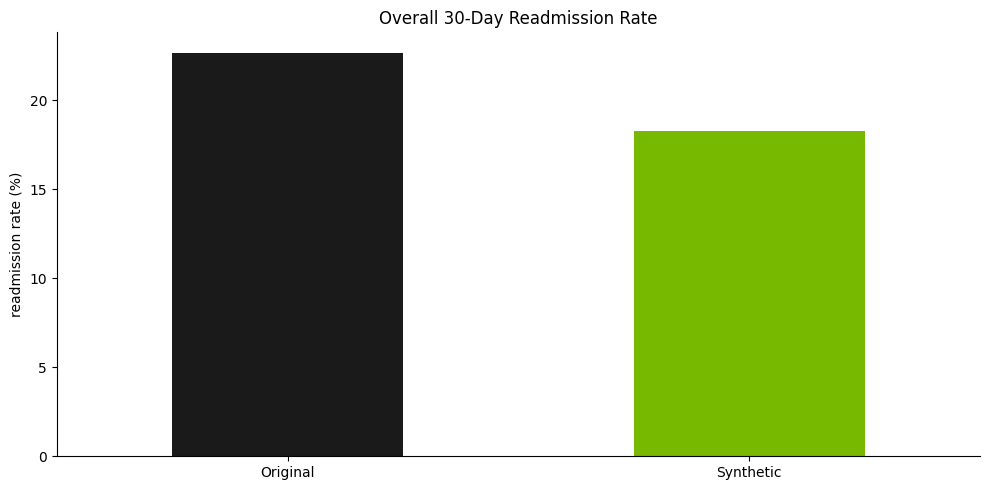

In [9]:
READMISSION = "readmitted_within_30_days"
NUMERIC = ["age", "length_of_stay_days", "total_charge_usd", "primary_lab_value"]
DATES = ["admission_datetime", "discharge_datetime", "date_of_birth"]

def prepare(frame: pd.DataFrame, label: str) -> pd.DataFrame:
    clean = frame.copy().assign(source=label)
    clean[READMISSION] = clean[READMISSION].astype("string").str.lower().map({"true": True, "false": False, "1": True, "0": False})
    clean[NUMERIC] = clean[NUMERIC].apply(pd.to_numeric, errors="coerce")
    for column in DATES:
        clean[column] = pd.to_datetime(clean[column], format="mixed", errors="coerce")
    return clean

original = prepare(source_df, "Original")
synthetic = prepare(synthetic_df, "Synthetic")
combined = pd.concat([original, synthetic], ignore_index=True)

overall_readmission = combined.groupby("source")[READMISSION].mean().mul(100)
axis = overall_readmission.plot.bar(color=[NVIDIA_DARK, NVIDIA_GREEN], title="Overall 30-Day Readmission Rate")
axis.set_ylabel("readmission rate (%)")
axis.set_xlabel("")
axis.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### Readmission patterns across cohorts

**What to look for:** Compare the relative ordering and broad differences across diagnoses, discharge dispositions, and insurance types, not just exact bar heights.

**What it means:** Similar subgroup patterns indicate that relationships between diagnosis, discharge disposition, insurance, and readmission were preserved. Large or reversed differences identify analyses that may not be reliable on the Synthetic data.

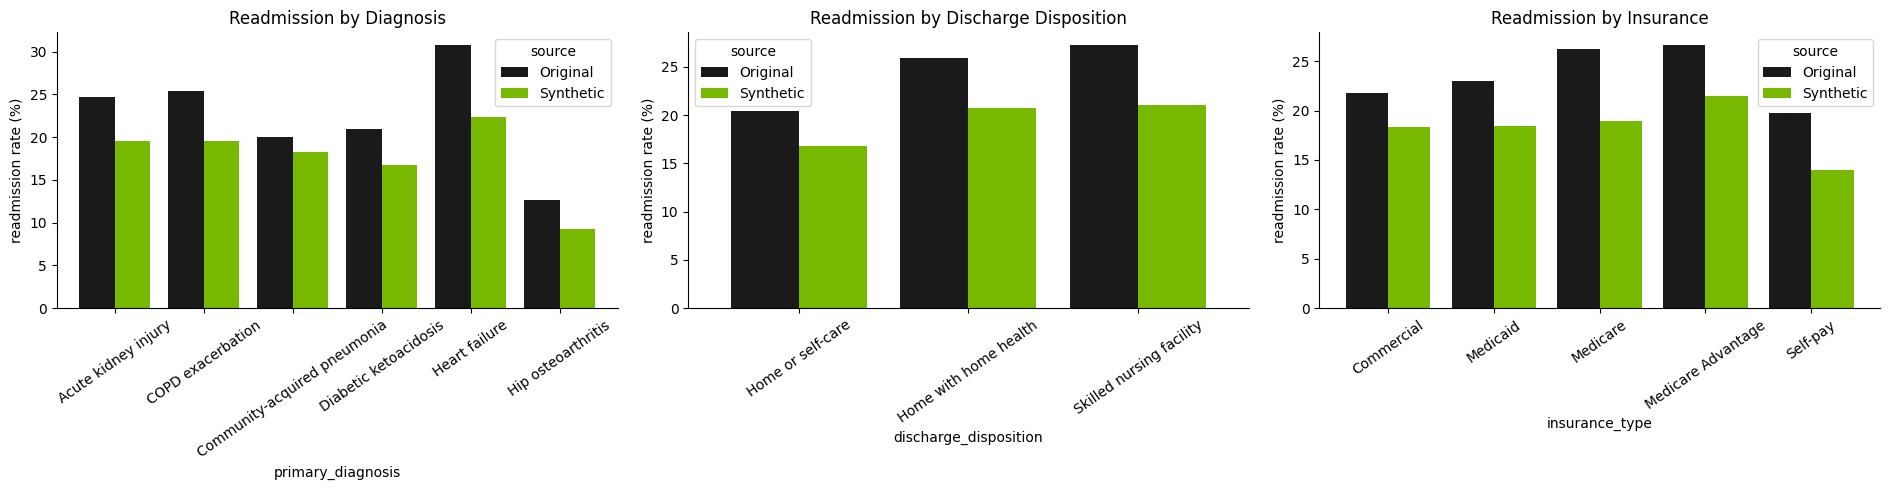

In [10]:
def readmission_by(column: str) -> pd.DataFrame:
    return combined.groupby([column, "source"])[READMISSION].mean().mul(100).unstack()

rate_tables = {
    "Diagnosis": readmission_by("primary_diagnosis"),
    "Discharge Disposition": readmission_by("discharge_disposition"),
    "Insurance": readmission_by("insurance_type"),
}
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for (title, table), axis in zip(rate_tables.items(), axes, strict=True):
    table.plot.bar(ax=axis, color=[NVIDIA_DARK, NVIDIA_GREEN], width=0.8, title=f"Readmission by {title}")
    axis.set_ylabel("readmission rate (%)")
    axis.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

### Insurance mix

**What to look for:** The proportions of major insurance categories should be broadly similar between the Original and Synthetic cohorts.

**What it means:** Insurance mix affects payer and access analyses. A shifted mix can bias conclusions even when the overall readmission rate looks similar.

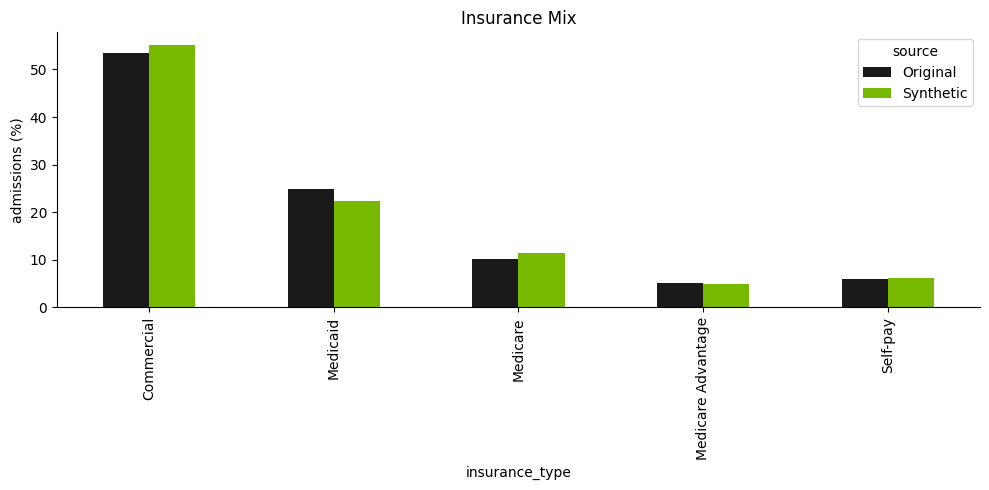

In [11]:
insurance_mix = combined.groupby("source")["insurance_type"].value_counts(normalize=True).mul(100).unstack(0)
axis = insurance_mix.plot.bar(color=[NVIDIA_DARK, NVIDIA_GREEN], title="Insurance Mix")
axis.set_ylabel("admissions (%)")
plt.tight_layout()
plt.show()

### Length of stay and total charges

**What to look for:** Compare the center, spread, skew, and tails of both distributions. The Synthetic data should reproduce the broad shape without copying individual records.

**What it means:** Compressed or exaggerated tails can distort capacity, utilization, and financial analyses even when averages are close.

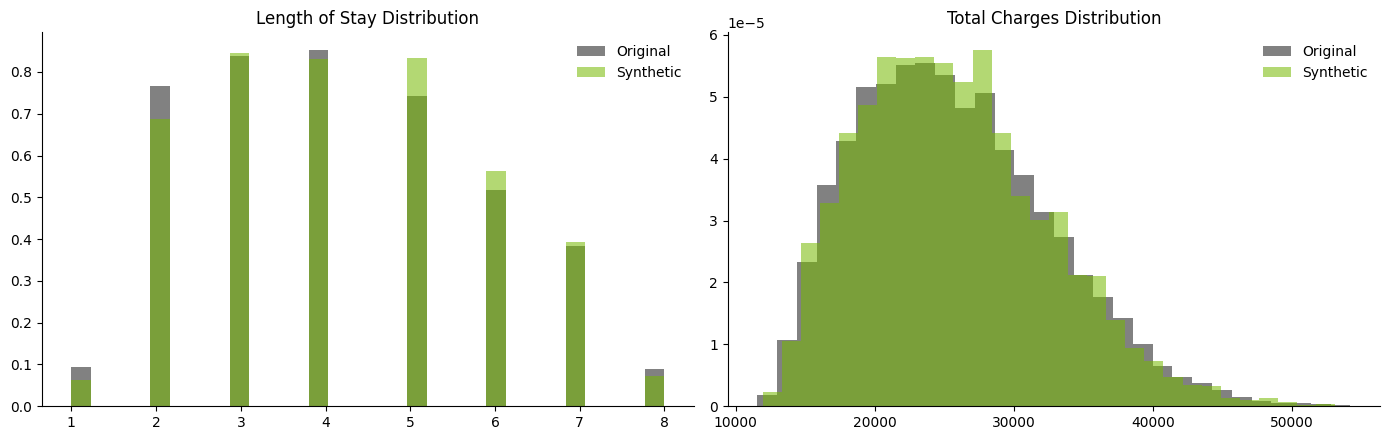

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plots = zip(axes, ["length_of_stay_days", "total_charge_usd"], ["Length of Stay", "Total Charges"], strict=True)
for axis, column, title in plots:
    for label, frame, color in [("Original", original, NVIDIA_DARK), ("Synthetic", synthetic, NVIDIA_GREEN)]:
        axis.hist(frame[column].dropna(), bins=30, density=True, alpha=0.55, label=label, color=color)
    axis.set_title(f"{title} Distribution")
    axis.legend(frameon=False)
plt.tight_layout()
plt.show()

### Clinical relationship and chronology checks

A useful hospital dataset must preserve more than single-column distributions. The following plots examine diagnosis-to-International Classification of Diseases (ICD) mappings, diagnosis-to-lab relationships, lab flag/reference-range agreement, and admission/discharge chronology.

#### Diagnosis mapping agreement

**What to look for:** Higher agreement means the Synthetic rows retain the diagnosis-to-ICD and diagnosis-to-primary-lab mappings observed in the Original data.

**What it means:** Plausible individual columns are not sufficient if their combinations are clinically inconsistent. Low agreement would limit code-based or laboratory-specific analyses.

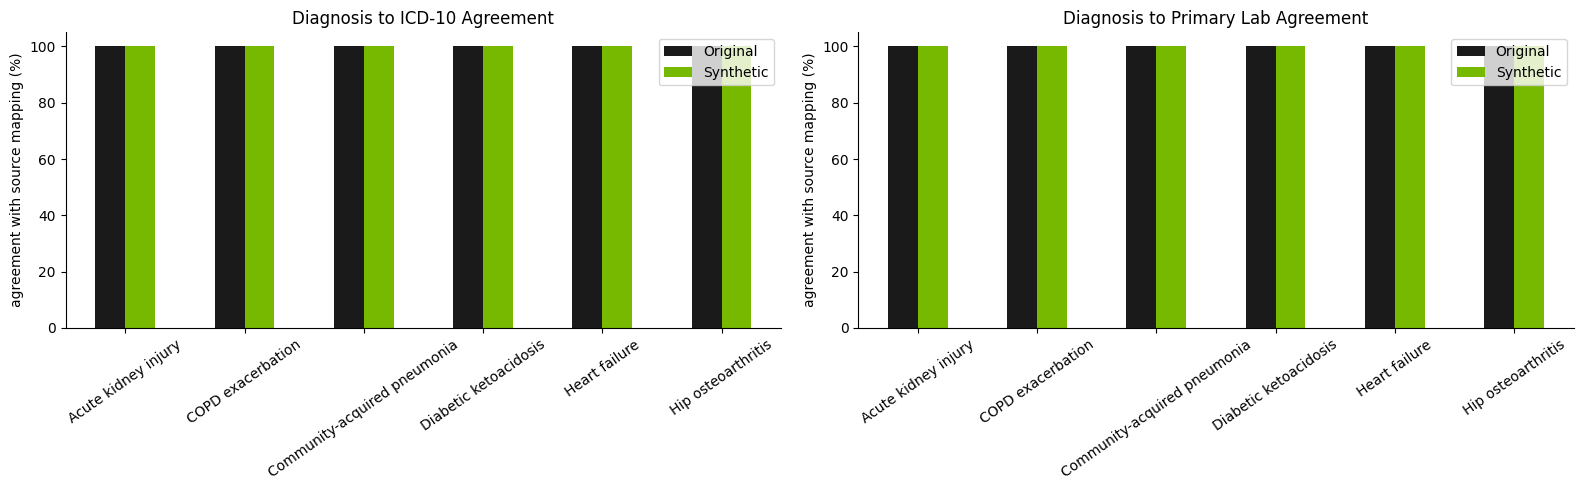

In [13]:
def relationship_agreement(frame: pd.DataFrame, column: str) -> pd.Series:
    expected = original.groupby("primary_diagnosis")[column].agg(lambda values: values.mode().iloc[0])
    matches = frame[column].eq(frame["primary_diagnosis"].map(expected))
    return matches.groupby(frame["primary_diagnosis"]).mean().mul(100)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
relationships = [("icd10_code", "Diagnosis to ICD-10"), ("primary_lab_name", "Diagnosis to Primary Lab")]
for axis, (column, title) in zip(axes, relationships, strict=True):
    agreement = pd.DataFrame({
        "Original": relationship_agreement(original, column),
        "Synthetic": relationship_agreement(synthetic, column),
    })
    agreement.plot.bar(ax=axis, color=[NVIDIA_DARK, NVIDIA_GREEN], title=f"{title} Agreement")
    axis.set_ylabel("agreement with source mapping (%)")
    axis.set_xlabel("")
    axis.set_ylim(0, 105)
    axis.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

#### Record-level clinical and chronological integrity

**What to look for:** Rates near 100% indicate that lab flags agree with reference ranges, discharge follows admission, recorded length of stay matches the timestamps, and age agrees with the dates.

**What it means:** These are basic record-validity checks. Failures can make individual Synthetic admissions unusable even when aggregate distributions appear accurate.

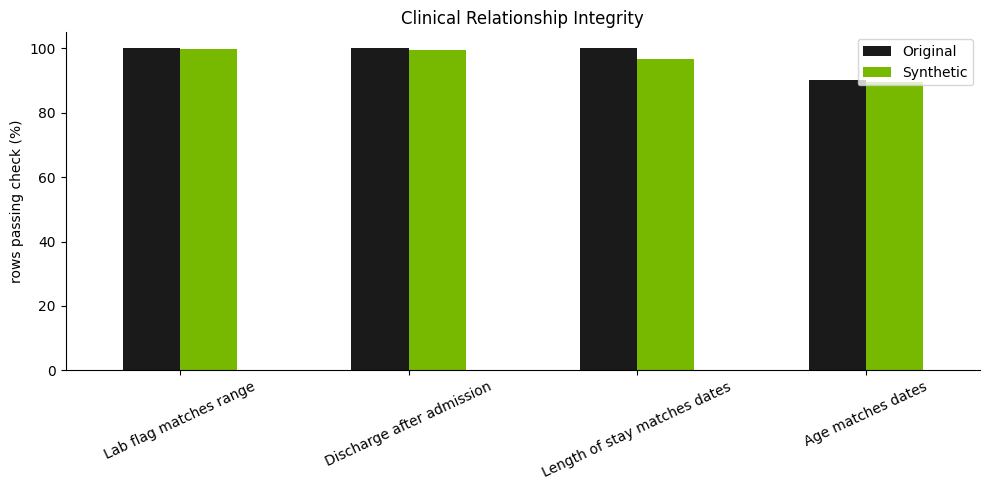

In [14]:
def clinical_integrity(frame: pd.DataFrame) -> dict:
    limits = frame["primary_lab_reference_range"].astype("string").str.extract(r"^\s*(-?\d+(?:\.\d+)?)\s*-\s*(-?\d+(?:\.\d+)?)\s*$").astype(float)
    expected_flag = pd.Series("N", index=frame.index)
    expected_flag.loc[frame["primary_lab_value"] < limits[0]] = "L"
    expected_flag.loc[frame["primary_lab_value"] > limits[1]] = "H"
    stay_days = (frame["discharge_datetime"] - frame["admission_datetime"]).dt.total_seconds() / 86_400
    age = (frame["admission_datetime"] - frame["date_of_birth"]).dt.days / 365.2425
    return {
        "Lab flag matches range": 100 * expected_flag.eq(frame["primary_lab_flag"].astype("string").str.upper()).mean(),
        "Discharge after admission": 100 * stay_days.ge(0).mean(),
        "Length of stay matches dates": 100 * stay_days.sub(frame["length_of_stay_days"]).abs().le(0.5).mean(),
        "Age matches dates": 100 * age.sub(frame["age"]).abs().le(2).mean(),
    }

integrity = pd.DataFrame({
    "Original": clinical_integrity(original),
    "Synthetic": clinical_integrity(synthetic),
})
axis = integrity.plot.bar(color=[NVIDIA_DARK, NVIDIA_GREEN], title="Clinical Relationship Integrity")
axis.set_ylabel("rows passing check (%)")
axis.set_xlabel("")
axis.set_ylim(0, 105)
axis.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 6. Train on Synthetic, Test on Real (TSTR)

Train-on-synthetic, test-on-real (TSTR) measures whether a model learned only from Synthetic records transfers to unseen Original records. Here, **real** is the conventional name for the test side of TSTR; it refers to the held-out Original input, which is itself simulated and contains no real patients. For comparison, train-on-real, test-on-real (TRTR) trains the same XGBoost classifier on the Original training partition. The 499-row holdout was set aside before fine-tuning, and both classifiers are tested on those same rows using the same discharge-time clinical and utilization features.

> **Utility is broader than matching model scores.** In production, analysts and developers may not be permitted to access or train directly on the Original data because it contains PHI or PII. A governed, privacy-reviewed Synthetic dataset can enable exploration, pipeline development, integration testing, and model prototyping that otherwise could not happen. The comparison below tests whether a model trained on the Synthetic data can make useful predictions on held-out Original data. Similar performance is only one dimension of utility and does not make the Synthetic data automatically safe to share.

**What to look for:** Compare the metric bars and receiver operating characteristic (ROC) curves for the Original-trained and Synthetic-trained models. The area under each ROC curve (AUC) summarizes how well a model ranks readmitted admissions above non-readmitted admissions across classification thresholds. Similar scores suggest that the Synthetic data preserved relationships useful for prediction, while a large gap indicates lost signal. Average precision should be read relative to the readmission prevalence, and balanced accuracy depends on the selected classification threshold.

**What it means:** This comparison demonstrates transfer to the simulated holdout; it is not clinical validation. A production study should test on a governed real-data holdout that was never used for synthesis. Direct identifiers, contact details, dates, and discharge-summary text are excluded from both classifiers, and neither model is intended for clinical use.

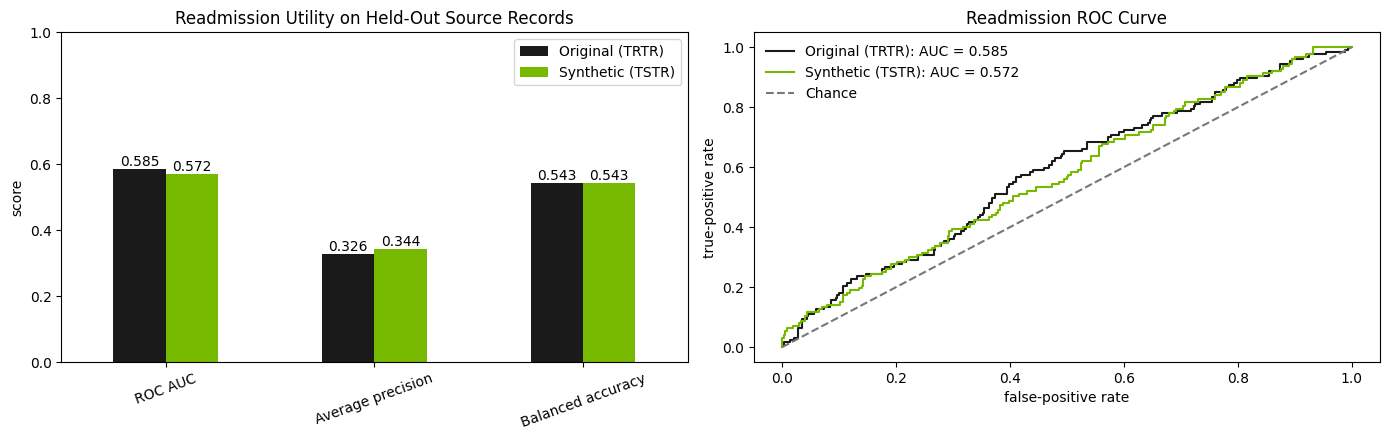

In [15]:
from sklearn.compose import make_column_transformer
from sklearn.metrics import average_precision_score, balanced_accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

TSTR_NUMERIC = ["age", "primary_lab_value", "length_of_stay_days", "total_charge_usd"]
TSTR_CATEGORICAL = [
    "sex", "race_ethnicity", "insurance_type", "encounter_type",
    "primary_diagnosis", "icd10_code", "comorbidities", "primary_lab_name",
    "primary_lab_unit", "primary_lab_reference_range", "primary_lab_flag",
    "medication", "procedure", "discharge_disposition",
]
TSTR_FEATURES = TSTR_NUMERIC + TSTR_CATEGORICAL

original_training_source, held_out_source = train_test_split(
    source_df, test_size=int(len(source_df) * 0.05), random_state=SPLIT_SEED
)
original_training = prepare(original_training_source.reset_index(drop=True), "Original training")
held_out = prepare(held_out_source.reset_index(drop=True), "Held-out source")

def readmission_model(training: pd.DataFrame):
    positive_weight = (~training[READMISSION]).sum() / training[READMISSION].sum()
    return make_pipeline(
        make_column_transformer(
            ("passthrough", TSTR_NUMERIC),
            (OneHotEncoder(handle_unknown="ignore"), TSTR_CATEGORICAL),
        ),
        XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            scale_pos_weight=positive_weight,
            tree_method="hist",
            random_state=SPLIT_SEED,
            n_jobs=4,
        ),
    )

training_sets = {"Original (TRTR)": original_training, "Synthetic (TSTR)": synthetic}
probabilities = {}
metrics = {}
for label, training in training_sets.items():
    model = readmission_model(training)
    model.fit(training[TSTR_FEATURES], training[READMISSION])
    probability = model.predict_proba(held_out[TSTR_FEATURES])[:, 1]
    probabilities[label] = probability
    metrics[label] = {
        "ROC AUC": roc_auc_score(held_out[READMISSION], probability),
        "Average precision": average_precision_score(held_out[READMISSION], probability),
        "Balanced accuracy": balanced_accuracy_score(held_out[READMISSION], probability >= 0.5),
    }
utility_metrics = pd.DataFrame(metrics)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
utility_metrics.plot.bar(
    ax=axes[0], color=[NVIDIA_DARK, NVIDIA_GREEN], title="Readmission Utility on Held-Out Source Records"
)
axes[0].set_ylabel("score")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f")
for (label, probability), color in zip(probabilities.items(), [NVIDIA_DARK, NVIDIA_GREEN], strict=True):
    false_positive_rate, true_positive_rate, _ = roc_curve(held_out[READMISSION], probability)
    axes[1].plot(
        false_positive_rate, true_positive_rate, color=color,
        label=f"{label}: AUC = {metrics[label]['ROC AUC']:.3f}",
    )
axes[1].plot([0, 1], [0, 1], linestyle="--", color="#777777", label="Chance")
axes[1].set(title="Readmission ROC Curve", xlabel="false-positive rate", ylabel="true-positive rate")
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()